In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.optimize import fmin_slsqp
from toolz import reduce, partial
import pyfixest as pf
from pyfixest import iplot
import random
from scpi_pkg.scdata import scdata
from scpi_pkg.scest import scest
from scpi_pkg.scplot import scplot

In [17]:
aqi_data = pd.read_csv("aqi_daily_1980_to_2021.csv")

In [18]:
rb_states = [
    "Illinois",
    "Indiana",
    "Michigan",
    "New York",
    "Ohio",
    "Pennsylvania",
    "West Virginia",
    "Wisconsin"
]

res_counties = ["Lake", "Marion", "Kent", "Macomb", "Wayne", "Monroe", "Hamilton", "Montgomery"]

rb_aqi_data = aqi_data[aqi_data["State Name"].isin(rb_states) & aqi_data["County Name"].isin(res_counties)]

rb_aqi_data["Date"] = pd.to_datetime(rb_aqi_data["Date"])
rb_aqi_data["year"] = rb_aqi_data["Date"].dt.year

rb_aqi_summary = (rb_aqi_data.groupby(["County Name", "Defining Parameter", "year"], as_index=False)["AQI"]
                  .mean().rename(columns={"AQI": "avg_aqi"}))

rb_aqi_summary = rb_aqi_summary[(rb_aqi_summary["year"] >= 2001) & (rb_aqi_summary["year"] <= 2010)]
rb_aqi_summary
#rb_aqi_summary.to_csv("aqi_summary.csv", index=False)

,County Name,Defining Parameter,year,avg_aqi
16,Hamilton,CO,2006,33.000000
40,Hamilton,NO2,2001,40.529412
41,Hamilton,NO2,2002,38.062500
42,Hamilton,NO2,2003,44.448276
43,Hamilton,NO2,2004,43.225806
...,...,...,...,...
1384,Wayne,SO2,2006,80.397436
1385,Wayne,SO2,2007,79.148148
1386,Wayne,SO2,2008,77.246377
1387,Wayne,SO2,2009,67.681818


In [19]:
rb_aqi_summary["treated"] = (rb_aqi_summary["County Name"] == "Wayne").astype(int)

rb_aqi_wide = (
    rb_aqi_summary
      .pivot_table(
          index=["County Name", "year"],     
          columns="Defining Parameter",
          values="avg_aqi",
          aggfunc="mean"
      )
      .reset_index()
)
rb_aqi_wide.columns.name = None

rb_aqi_wide["treated"] = (rb_aqi_wide["County Name"] == "Wayne").astype(int)




In [20]:
rb_aqi_wide

,County Name,year,CO,NO2,Ozone,PM10,PM2.5,SO2,treated
0,Hamilton,2001,NaN,40.529412,52.940547,NaN,66.582011,98.904110,0
1,Hamilton,2002,NaN,38.062500,59.468750,NaN,60.465608,89.337349,0
2,Hamilton,2003,NaN,44.448276,54.018703,NaN,61.238318,78.043478,0
3,Hamilton,2004,NaN,43.225806,48.139334,NaN,60.497110,83.181818,0
4,Hamilton,2005,NaN,38.010526,54.101176,NaN,67.382979,67.258427,0
...,...,...,...,...,...,...,...,...,...
75,Wayne,2006,NaN,31.227273,41.375862,41.181818,65.434286,80.397436,1
76,Wayne,2007,NaN,33.352941,53.932075,47.750000,59.970732,79.148148,1
77,Wayne,2008,NaN,27.925926,44.460526,29.142857,55.994536,77.246377,1
78,Wayne,2009,NaN,31.555556,39.028125,41.000000,52.792929,67.681818,1


In [21]:
pollutants = [c for c in rb_aqi_wide.columns if c not in ["County Name", "year", "treated"]] 

#checking which pollutants have complete data across all counties and years
available_thru_out = [
    c for c in pollutants
    if rb_aqi_wide[c].notna().all()
]

print(available_thru_out)
rb_aqi_pmo = rb_aqi_wide[["County Name", "year", "treated", "Ozone", "PM2.5"]].copy()
rb_aqi_pmo

['Ozone', 'PM2.5']


,County Name,year,treated,Ozone,PM2.5
0,Hamilton,2001,0,52.940547,66.582011
1,Hamilton,2002,0,59.468750,60.465608
2,Hamilton,2003,0,54.018703,61.238318
3,Hamilton,2004,0,48.139334,60.497110
4,Hamilton,2005,0,54.101176,67.382979
...,...,...,...,...,...
75,Wayne,2006,1,41.375862,65.434286
76,Wayne,2007,1,53.932075,59.970732
77,Wayne,2008,1,44.460526,55.994536
78,Wayne,2009,1,39.028125,52.792929


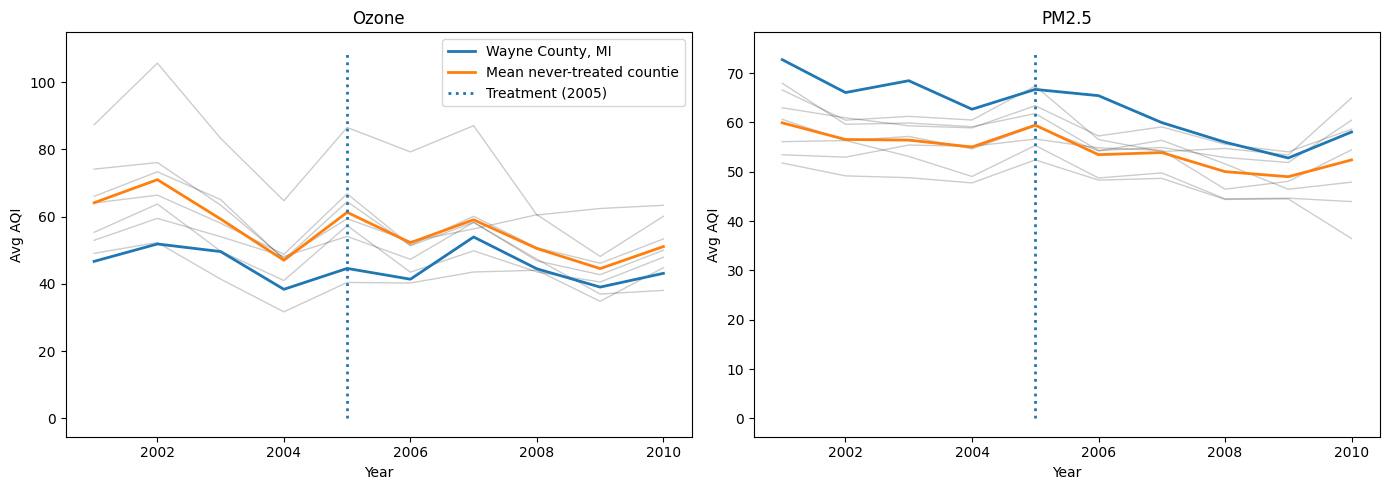

In [22]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for ax, col in zip(axes, ["Ozone", "PM2.5"]):
    for _, gdf in rb_aqi_pmo.groupby("County Name"):
        ax.plot(gdf["year"], gdf[col], alpha=0.2, lw=1, color="k")
    wayne = rb_aqi_pmo[rb_aqi_pmo["County Name"] == "Wayne"]
    ax.plot(wayne["year"], wayne[col], label="Wayne County, MI", lw=2)
    (
        rb_aqi_pmo[rb_aqi_pmo["County Name"] != "Wayne"]
        .groupby("year")[col]
        .mean()
        .plot(ax=ax, label="Mean never-treated countie", lw=2)
    )
    ymax = ax.get_ylim()[1]
    ax.vlines(x=2005, ymin=0, ymax=ymax, linestyle=":", lw=2, label="Treatment (2005)")
    ax.set_title(col)
    ax.set_xlabel("Year")
    ax.set_ylabel("Avg AQI")

axes[0].legend()
plt.tight_layout()
plt.show()


In [23]:
rb_aqi_pmo.rename(columns={
    "County Name": "county",
    "PM2.5": "pm25",
    "Ozone": "ozone",
}, inplace=True)# reformatting the columns so that twfe doesnt complain

pm25_twfe = pf.feols(
    'pm25 ~ i(year, treated, ref=2004) | Q("county") + year',
    rb_aqi_pmo,
    vcov={"CRV1": "county"},
)

ozone_twfe = pf.feols(
    'ozone ~ i(year, treated, ref=2004) | Q("county") + year',
    rb_aqi_pmo,
    vcov={"CRV1": "county"},
)

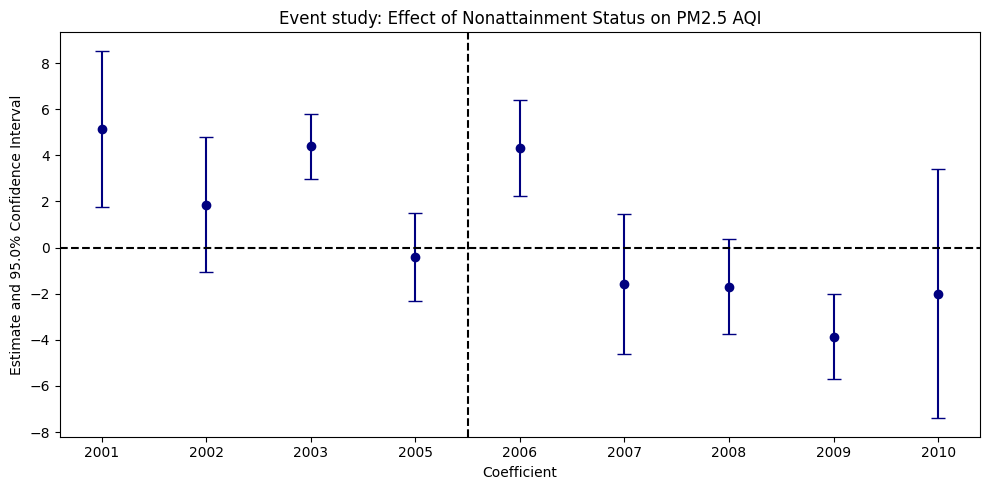

In [24]:
pm25_twfe.iplot(
    coord_flip=False,
    figsize=(10, 5),
    yintercept=0,  
    cat_template="{value_int}",
    xintercept=3.5,
    title="Event study: Effect of Nonattainment Status on PM2.5 AQI",
)

## PM2.5 Synthetic Control 

In [ ]:
treat_year = 2005
features = ["pm25"]


pre = rb_aqi_pmo.query("year < @treat_year")[["county","year","pm25"]].dropna()
pre_mean = pre.groupby("county")["pm25"].mean()#pre-treatment average by county
rb_aqi_pmo["pm25_dm"] = rb_aqi_pmo["pm25"] - rb_aqi_pmo["county"].map(pre_mean)#deviation from the pre-treatment average

features = ["pm25_dm"]

inverted = (
    rb_aqi_pmo.query("year < @treat_year")      
          .pivot(index="county", columns="year")[features]  
          .T                               
)
inverted


county        Hamilton      Kent      Lake    Macomb    Marion    Monroe  \
        year                                                               
pm25_dm 2001  4.386249 -0.801204  6.306749  2.401112  2.440157  2.452678   
        2002 -1.730153 -1.279111 -2.031097 -0.203390  0.409877  2.683939   
        2003 -0.957444  1.168151 -1.763837 -0.569404 -1.214285 -0.532325   
        2004 -1.698652  0.912163 -2.511815 -1.628319 -1.635748 -4.604291   

county        Montgomery     Wayne  
        year                        
pm25_dm 2001    3.443770  5.248021  
        2002   -0.869946 -1.421124  
        2003   -0.025860  0.980971  
        2004   -2.547964 -4.807869

In [31]:
X1 = inverted["Wayne"].values               

X0_names = [c for c in inverted.columns if c != "Wayne"]
X0 = inverted[X0_names].values              

def loss_w(W, X0, X1) -> float:
    diff = (X1 - X0.dot(W)) 
    return np.mean(diff**2)

def get_w(X0, X1):
    w_start = [1 / X0.shape[1]] * X0.shape[1]   
    weights = fmin_slsqp(
        partial(loss_w, X0=X0, X1=X1),
        np.array(w_start),
        f_eqcons=lambda x: np.sum(x) - 1,      
        bounds=[(0.0, 1.0)] * len(w_start),    
        disp=False
    )
    return weights

wayne_weights = get_w(X0, X1)


wayne_weights_series = pd.Series(wayne_weights, index=X0_names, name="weight")
print(wayne_weights_series.sort_values(ascending=False))

wayne_weights.sum()


Montgomery    4.528515e-01
Lake          3.921708e-01
Monroe        1.549777e-01
Marion        8.445767e-16
Kent          5.778052e-16
Hamilton      5.435059e-16
Macomb        0.000000e+00
Name: weight, dtype: float64


np.float64(1.0000000000000002)

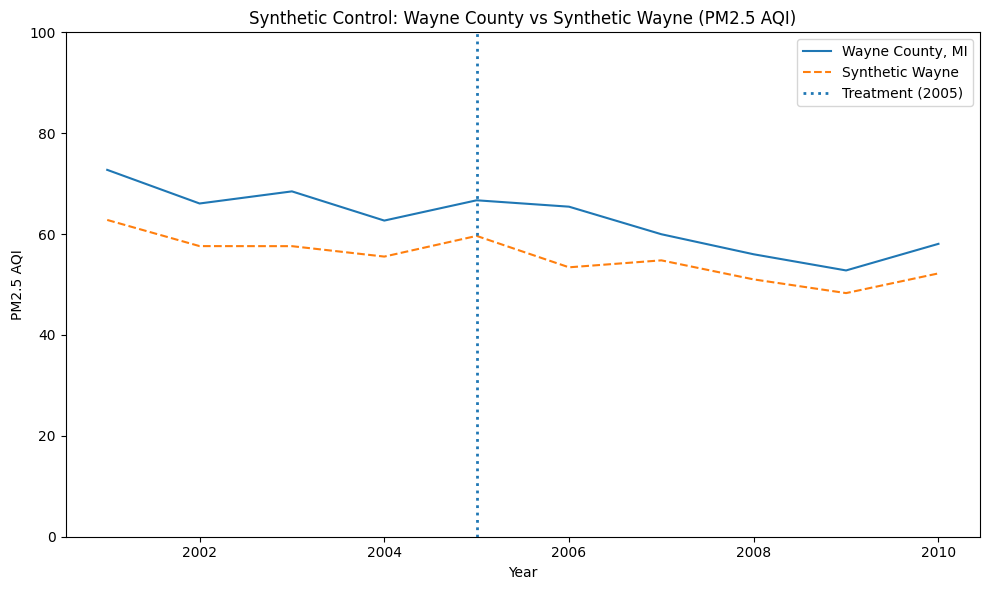

In [33]:
X0_panel = (
    rb_aqi_pmo.query('county != "Wayne"')
          .pivot(index="year", columns="county")["pm25"]
          .sort_index()
)

X0_panel = X0_panel[X0_names]

wayne_synth = X0_panel.values.dot(wayne_weights)

wayne_actual = (
    rb_aqi_pmo[rb_aqi_pmo["county"] == "Wayne"]
    .sort_values("year")
    .set_index("year")["pm25"]
)

years = X0_panel.index  

# Plot the results

plt.figure(figsize=(10, 6))
plt.plot(wayne_actual.index, wayne_actual.values, label="Wayne County, MI")
plt.plot(years, wayne_synth, label="Synthetic Wayne", linestyle="--")

plt.vlines(x=2005, ymin=0, ymax=100, linestyle=":", lw=2, label="Treatment (2005)")
plt.ylim(0, 100)

plt.ylabel("PM2.5 AQI")
plt.xlabel("Year")
plt.title("Synthetic Control: Wayne County vs Synthetic Wayne (PM2.5 AQI)")
plt.legend()
plt.tight_layout()
plt.show()


In [40]:
rb_aqi_pmo["post"] = (rb_aqi_pmo["year"] >= 2005).astype(int)
rb_aqi_pmo

,county,year,treated,ozone,pm25,pm25_dm,post
0,Hamilton,2001,0,52.940547,66.582011,4.386249,0
1,Hamilton,2002,0,59.468750,60.465608,-1.730153,0
2,Hamilton,2003,0,54.018703,61.238318,-0.957444,0
3,Hamilton,2004,0,48.139334,60.497110,-1.698652,0
4,Hamilton,2005,0,54.101176,67.382979,5.187217,1
...,...,...,...,...,...,...,...
75,Wayne,2006,1,41.375862,65.434286,-2.052828,1
76,Wayne,2007,1,53.932075,59.970732,-7.516382,1
77,Wayne,2008,1,44.460526,55.994536,-11.492578,1
78,Wayne,2009,1,39.028125,52.792929,-14.694185,1


In [51]:
pre = sorted(rb_aqi_pmo.loc[rb_aqi_pmo["post"] == 0, "year"].unique().tolist())
post = sorted(rb_aqi_pmo.loc[rb_aqi_pmo["post"] == 1, "year"].unique().tolist())

unit_tr = "Wayne"
unit_co = sorted(rb_aqi_pmo.loc[rb_aqi_pmo["county"] != unit_tr, "county"].unique().tolist())


pmdf = scdata(df=rb_aqi_pmo, id_var="county", time_var="year", outcome_var="pm25_dm",
              period_pre=np.array(pre), period_post=np.array(post),
              unit_tr=unit_tr, unit_co=unit_co, features=["pm25_dm"], cov_adj=None,
              cointegrated_data=True, constant=False)


-----------------------------------------------------------------------
Call: scest
Synthetic Control Estimation - Setup

Constraint Type:                                           simplex
Constraint Size (Q):                                             1
Treated Unit:                                                Wayne
Size of the donor pool:                                          7
Features                                                         1
Pre-treatment period                                     2001-2004
Pre-treatment periods used in estimation:                        4
Covariates used for adjustment:                                  0

Synthetic Control Estimation - Results

Active donors: 3

Coefficients:
                         Weights
Treated Unit Donor              
Wayne        Hamilton      0.000
             Kent         -0.000
             Lake          0.392
             Macomb        0.000
             Marion        0.000
             Monroe        0.155
     

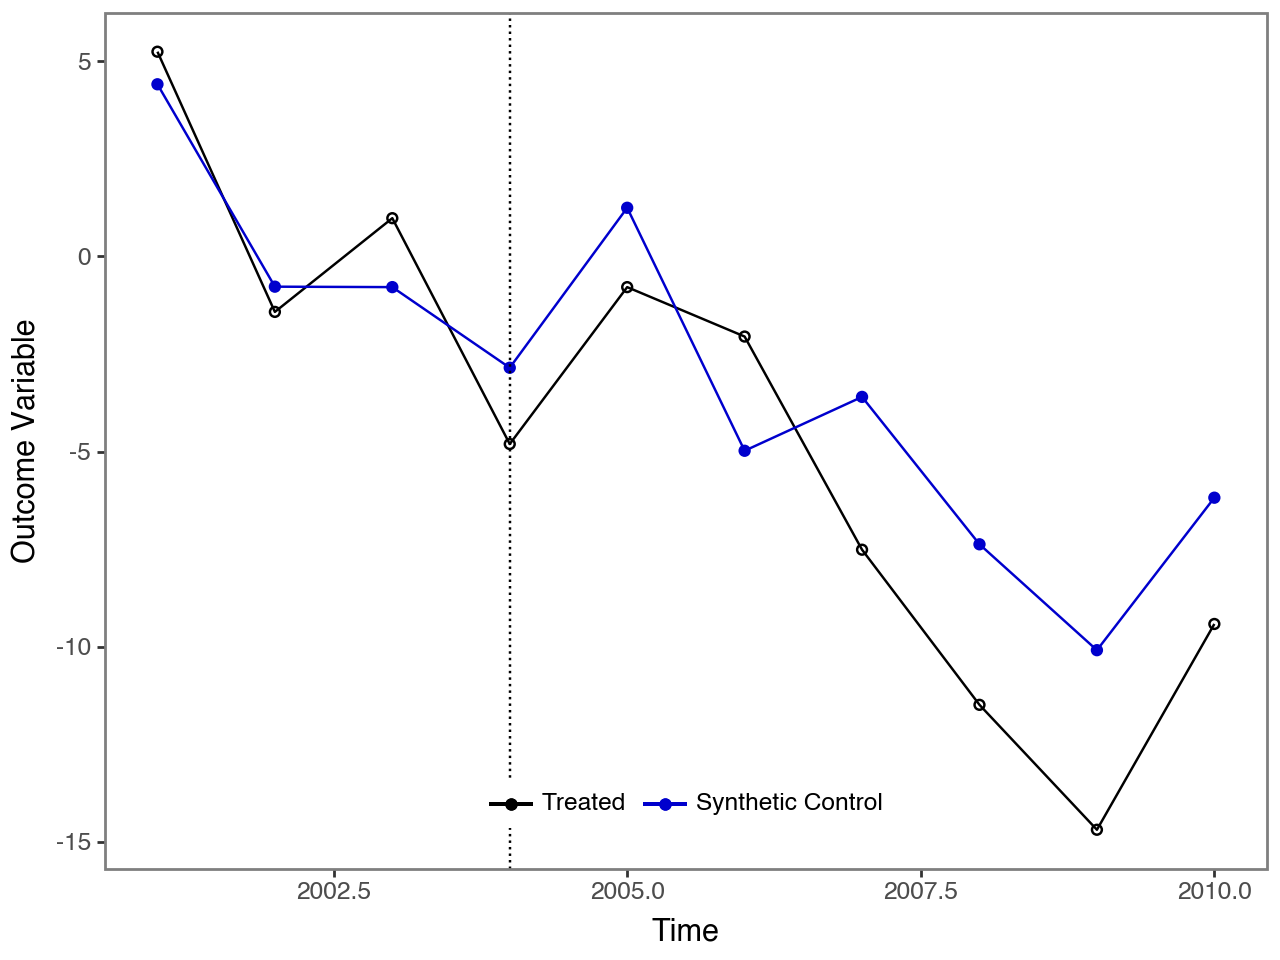

In [52]:
est_si = scest(pmdf, w_constr={'name': "simplex"})
print(est_si)
est_si2 = scest(pmdf, w_constr={'p': 'L1', 'dir': '==', 'Q': 1, 'lb': 0})
print(est_si2)
scplot(est_si)

-----------------------------------------------
Estimating Weights...
Quantifying Uncertainty

terations completed (10%)
terations completed (20%)
terations completed (30%)
terations completed (40%)


/Users/wayneren/grad_courses/econ526/project/epa_greenbook_project/.venv/lib/python3.12/site-packages/scpi_pkg/scpi.py:775: UserWarning: One of u_order > 0 and  u_lags > 0 was specified, however the current number of observations (3) used to estimate conditional moments of the pseudo-residuals is not larger than the number of parameters used in estimation (3) plus 10. To avoid over-fitting issues u_order and u_lags were set to 0.
/Users/wayneren/grad_courses/econ526/project/epa_greenbook_project/.venv/lib/python3.12/site-packages/scpi_pkg/scpi.py:977: UserWarning: One of e_order > 0 and e_lags > 0 was specified, however the current number of observations (3) used to estimate conditional moments of the out-of-sample error is not larger than the number of parameters used in estimation (3) plus 10. To avoid over-fitting issues e_order and e_lags were set to 0.



iterations completed (60%)
iterations completed (70%)
iterations completed (80%)
iterations completed (90%)


/Users/wayneren/grad_courses/econ526/project/epa_greenbook_project/.venv/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_errorbar : Removed 4 rows containing missing values.


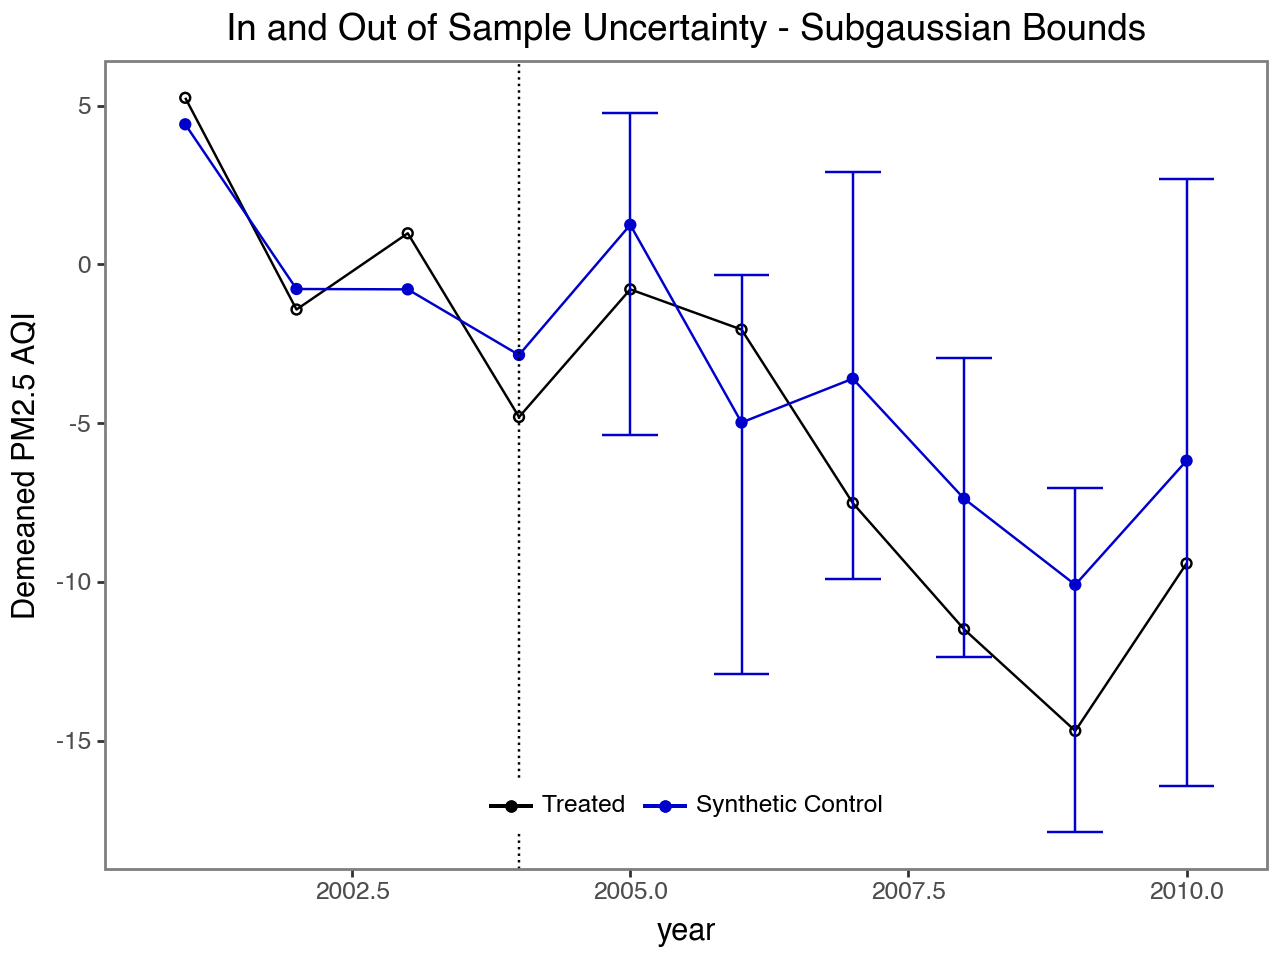

In [54]:
from scpi_pkg.scpi import scpi

w_constr = {'name': 'simplex', 'Q': 1}
u_missp = True
u_sigma = "HC1"
u_order = 1
u_lags = 0
e_method = "gaussian"
e_order = 1
e_lags = 0
e_alpha = 0.05
u_alpha = 0.05
sims = 200
cores = 1

random.seed(8894)
result = scpi(pmdf, sims=sims, w_constr=w_constr, u_order=u_order, u_lags=u_lags,
              e_order=e_order, e_lags=e_lags, e_method=e_method, u_missp=u_missp,
              u_sigma=u_sigma, cores=cores, e_alpha=e_alpha, u_alpha=u_alpha)
scplot(result, e_out=True, x_lab="year", y_lab="Demeaned PM2.5 AQI")